In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os

import pandas as pd

import legwork as lw
import astropy.units as u
import numpy as np

In [2]:
DCO_TYPES = ["NSWD", "NSNS", "BHWD", "BHNS", "BHBH"]
kstar_masks = [([13], [10, 11, 12]), ([13], [13]), ([14], [10, 11, 12]), ([14], [13]), ([14], [14])]
FOLDER = "/mnt/ceph/users/twagg/lisa-dcos/fiducial"

In [7]:
for kstars, dco_type in zip(kstar_masks, DCO_TYPES):
    if dco_type != "BHBH":
        continue
    print(f"Processing {dco_type}...")
    all_formation_rows = None
    for file in os.listdir(FOLDER):
        if file.startswith(f"{dco_type}_Z_"):
            print(f"  Adding file: {file}")
            initC = cosmic.output.load_initC(f"{FOLDER}/{file}", key="initC")
            bpp = pd.read_hdf(f"{FOLDER}/{file}", key="bpp")
            k_lo, k_hi = kstars
            mask = ((
                (bpp["kstar_1"].isin(k_lo)) & (bpp["kstar_2"].isin(k_hi))
            ) | (
                (bpp["kstar_1"].isin(k_hi)) & (bpp["kstar_2"].isin(k_lo))
            )) & (bpp["sep"] > 0)
            if mask.sum() == 0:
                print(f"    No {dco_type} systems found in this file.")
                continue
            formation_rows = bpp[mask].drop_duplicates(subset="bin_num")[["tphys", "mass_1", "mass_2", "kstar_1", "kstar_2", "sep", "ecc", "bin_num"]]
            formation_rows["metallicity"] = initC["metallicity"].iloc[0]

            with h5.File(f"{FOLDER}/{file}", "r") as f:
                formation_rows["weights"] = f["stroopwafel"]["weights"][...][f["stroopwafel"]["is_hit"][...]]

            if all_formation_rows is None:
                all_formation_rows = formation_rows
            else:
                all_formation_rows = pd.concat([all_formation_rows, formation_rows], ignore_index=True)
    all_formation_rows.to_hdf(f"{FOLDER}/{dco_type}_formation_rows.h5", key="formation_rows", mode="w")

Processing BHBH...
  Adding file: BHBH_Z_0.00415.h5
  Adding file: BHBH_Z_0.00115.h5
  Adding file: BHBH_Z_0.01182.h5
  Adding file: BHBH_Z_0.00129.h5
  Adding file: BHBH_Z_0.01492.h5
  Adding file: BHBH_Z_0.02377.h5
    No BHBH systems found in this file.
  Adding file: BHBH_Z_0.0026.h5
  Adding file: BHBH_Z_0.0002.h5
  Adding file: BHBH_Z_0.02116.h5
  Adding file: BHBH_Z_0.00011.h5
  Adding file: BHBH_Z_0.00145.h5
  Adding file: BHBH_Z_0.00025.h5
  Adding file: BHBH_Z_0.0267.h5
    No BHBH systems found in this file.
  Adding file: BHBH_Z_0.00016.h5
  Adding file: BHBH_Z_0.0001.h5
  Adding file: BHBH_Z_0.00369.h5
  Adding file: BHBH_Z_0.00029.h5
  Adding file: BHBH_Z_0.00091.h5
  Adding file: BHBH_Z_0.03.h5
    No BHBH systems found in this file.
  Adding file: BHBH_Z_0.00834.h5
  Adding file: BHBH_Z_0.00032.h5
  Adding file: BHBH_Z_0.0004.h5
  Adding file: BHBH_Z_0.00013.h5
  Adding file: BHBH_Z_0.00292.h5
  Adding file: BHBH_Z_0.01328.h5
  Adding file: BHBH_Z_0.00057.h5
  Adding fi

In [8]:
dco_type = "BHBH"
kick_infos = [pd.read_hdf(f"{FOLDER}/{file}", key="kick_info")[
    ["tphys", "star", "delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1", "bin_num"]
] for file in os.listdir(FOLDER) if file.startswith(f"{dco_type}_Z_")]

In [9]:
all_kick_infos = pd.concat(kick_infos, ignore_index=True)
all_kick_infos.index = all_kick_infos.index.values // 2

In [10]:
all_kick_infos.to_hdf(f"{FOLDER}/{dco_type}_kick_info.h5", key="kick_info", mode="w")

In [58]:
all_formation_rows = pd.read_hdf(f"{FOLDER}/{dco_type}_formation_rows.h5", key="formation_rows")

In [84]:
N = 10_000_0000
s = lw.source.Source(
    m_1=all_formation_rows["mass_1"].values[:N] * u.Msun,
    m_2=all_formation_rows["mass_2"].values[:N] * u.Msun,
    ecc=all_formation_rows["ecc"].values[:N] * u.dimensionless_unscaled,
    a=all_formation_rows["sep"].values[:N] * u.Rsun,
    dist=np.full(len(all_formation_rows), 8)[:N] * u.kpc,
    interpolate_g=False,
    n_proc=28
)

In [85]:
merger_times = s.get_merger_time(exact=False)

In [86]:
merger_times

<Quantity [0.92064125, 0.14068622, 2.89982714, ..., 7.37982187, 0.02091155,
           0.73508567] Gyr>

In [87]:
s.m_1

<Quantity [ 9.00852903,  3.85121529, 23.17378805, ...,  7.16966588,
            6.0047431 , 11.3130957 ] solMass>

In [88]:
all_formation_rows

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,bin_num,metallicity,weights
0,7.809487,9.008529,3.910624,14,14,8.003937,0.318408,7,0.00415,0.020880
1,13.323229,3.851215,3.366364,14,14,4.270218,0.559407,307,0.00415,0.078090
2,5.838019,23.173788,7.480383,14,14,593.854281,0.991851,346,0.00415,0.114977
3,13.277874,4.359625,3.355746,14,14,3.492326,0.150492,451,0.00415,0.073704
4,9.624079,10.630558,4.650176,14,14,15.533850,0.563622,825,0.00415,0.048772
...,...,...,...,...,...,...,...,...,...,...
17227424,7.890987,13.176163,8.854272,14,14,28.631062,0.533720,1999295,0.00742,0.161089
17227425,5.778966,6.852809,5.574337,14,14,32.153030,0.828760,1999644,0.00742,0.063300
17227426,5.687546,7.169666,5.783745,14,14,12.804020,0.062935,1999794,0.00742,0.062137
17227427,5.454184,6.004743,5.940652,14,14,9.652725,0.875300,1999831,0.00742,0.133655


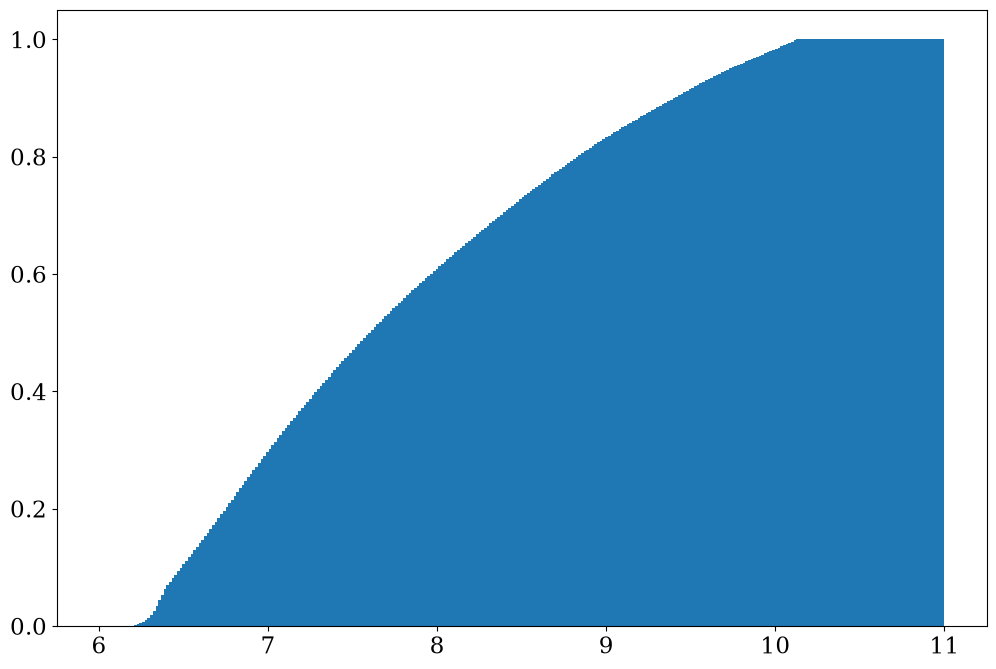

In [77]:
plt.hist(np.log10(merger_times.to(u.yr).value), bins="auto", cumulative=True, density=True, range=(6, 11))
plt.show()

# Test galaxy stuff

In [39]:
import sys
sys.path.append("../helpers")

from sfh import SB15PhiCut
import gala.potential as gp
import cogsworth
import matplotlib.pyplot as plt

In [68]:
class SB15PhiCut(cogsworth.sfh.SandersBinney2015):
    def __init__(self, phi_cut=0, *args, **kwargs):
        self.phi_cut = phi_cut
        super().__init__(*args, **kwargs)
        

    def _generate_df(self, J, component, tau):
        """Generate a distribution function for a given component and lookback time

        Follows `Sanders & Binney 2015 <https://ui.adsabs.harvard.edu/abs/2015MNRAS.449.3479S/abstract>`_
        Eq. 3.1.

        Parameters
        ----------
        J : `array-like`, shape (N, 3)
            Actions in (J_r, J_phi, J_z) in units of kpc^2 / Myr
        component : `str`
            Either "thin_disc" or "thick_disc"
        tau : :class:`~astropy.units.Quantity` [time]
            Lookback time

        Returns
        -------
        df_val : `array-like`, shape (N,)
            Value of the distribution function at the given actions
        """
        assert component in ["thin_disc", "thick_disc"], "Component must be 'thin_disc' or 'thick_disc'"

        J_r, J_z, J_phi = J.T

        # only compute the DF where the prior interpolations are valid
        df_val = np.zeros_like(J_r)
        valid = (J_phi >= 1e-5) & (J_phi <= 100)

        R_d = 3.45 if component == "thin_disc" else 2.31
        L_0 = 0.01

        # get guiding radii
        R_g = np.zeros_like(J_r)
        R_g[valid] = self._guiding_radius_interp(J_phi[valid])
        valid &= (R_g >= 1e-2) & (R_g <= 100)
        R_g = R_g[valid]

        # get frequencies at guiding radii based on potential
        omega = self._omega_interp(R_g)
        kappa = self._kappa_interp(R_g)
        nu = self._nu_interp(R_g)

        # time dependent velocity dispersions
        kms_to_kpcMyr = (u.km / u.s).to(u.kpc / u.Myr)
        sigma_R = self._get_sigma_i("R", R_g, tau, component) * kms_to_kpcMyr
        sigma_z = self._get_sigma_i("z", R_g, tau, component) * kms_to_kpcMyr

        # construct DF
        prefactor = 1 / (8 * np.pi**3) * (1 + np.tanh(J_phi[valid] / L_0))          # no units
        exp_terms = [
            omega / (R_d**2 * kappa**2) * np.exp(-R_g / R_d),                       # units of Myr/kpc^2
            (kappa / sigma_R**2) * np.exp(-kappa * J_r[valid] / sigma_R**2),        # units of Myr/kpc^2
            (nu / sigma_z**2) * np.exp(-nu * J_z[valid] / sigma_z**2)               # units of Myr/kpc^2
        ]
        df_val[valid] = prefactor * np.prod(exp_terms, axis=0)                      # units of Myr^3/kpc^6

        df_val[(J_phi < self.phi_cut)] = 0

        return df_val

In [69]:
regular = SB15PhiCut(phi_cut=0, potential=gp.MilkyWayPotential(version='v2'))
low_Z = SB15PhiCut(phi_cut=3.5, potential=gp.MilkyWayPotential(version='v2'))

In [151]:
uni, cnt = np.unique(all_formation_rows["metallicity"].values, return_counts=True)

In [152]:
np.sum([min(c * 10, 5_000) for c in cnt])

np.int64(213850)

In [148]:
rand_sample = all_formation_rows.sample(200_000)

In [149]:
Z_BIN_CENTRES = np.logspace(-4, np.log10(0.03), 50)
BIN_WIDTH = (np.log10(Z_BIN_CENTRES)[1] - np.log10(Z_BIN_CENTRES)[0]) / 2
Z_BIN_EDGES = np.logspace(np.log10(Z_BIN_CENTRES[0]) - BIN_WIDTH, np.log10(Z_BIN_CENTRES[-1]) + BIN_WIDTH, 51)
Z_BIN_EDGES[0] = Z_BIN_CENTRES[0]
Z_BIN_EDGES[-1] = Z_BIN_CENTRES[-1]

In [153]:
counts, _ = np.histogram(rand_sample["metallicity"].values, bins=Z_BIN_EDGES)
low_counts = counts.copy()
low_counts[30:] = 0
high_counts = counts.copy()
high_counts[:30] = 0

In [154]:
low_counts.sum()

np.int64(192940)

In [155]:
low_galaxy_counts = np.zeros_like(counts)
rnd = 0
while np.sum(low_galaxy_counts) < np.sum(low_counts):
    print(f"Round {rnd}: Current low galaxy counts: {np.sum(low_galaxy_counts)} / {np.sum(low_counts)}")
    print("  Missing counts per bin: ", low_counts - low_galaxy_counts)
    low_Z.sample(1_000_000)
    low_Z.Z[low_Z.Z < 1e-4] = 1e-4
    low_Z.Z[low_Z.Z > 0.03] = 0.03

    for i in range(len(low_counts)):
        if low_galaxy_counts[i] == low_counts[i]:
            continue

        matches = (Z_BIN_EDGES[i] <= low_Z.Z.value) & (low_Z.Z.value < Z_BIN_EDGES[i+1])
        low_galaxy_counts[i] = min(low_counts[i], low_galaxy_counts[i] + matches.sum())

    rnd += 1

Round 0: Current low galaxy counts: 0 / 192940
  Missing counts per bin:  [3474 3859 4501 4709 5524 6278 6800 7082 7381 7382 7873 7803 8000 7958
 7984 8107 8121 7991 7599 7506 7283 6996 6949 6538 6056 5633 5340 4812
 4059 3342    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
Round 1: Current low galaxy counts: 191359 / 192940
  Missing counts per bin:  [1581    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [119]:
rand_sample["metallicity"].values.min()

np.float64(0.0001)